<a href="https://colab.research.google.com/github/ntu-dl-bootcamp/deep-learning-2026/blob/main/SESSION5/session5b_flappy_bird_studentversion.ipynb" target="_blank"><img alt="Open In Colab" src="https://colab.research.google.com/assets/colab-badge.svg"/></a>

# RL Bootcamp (S5): Flappy Bird

Goal: to build an environment for Flappy Bird game, train and evaluate the Reinforcement Learning agent using DQN algorithm, using StableBaseline library.

Flappy Bird is a simple game where you tap the screen to make the bird fly upward. The bird falls down if you don’t tap. You must avoid hitting pipes and try to pass through the gaps. Each time you pass a pipe, you get a point. The goal is to get the highest score without crashing.

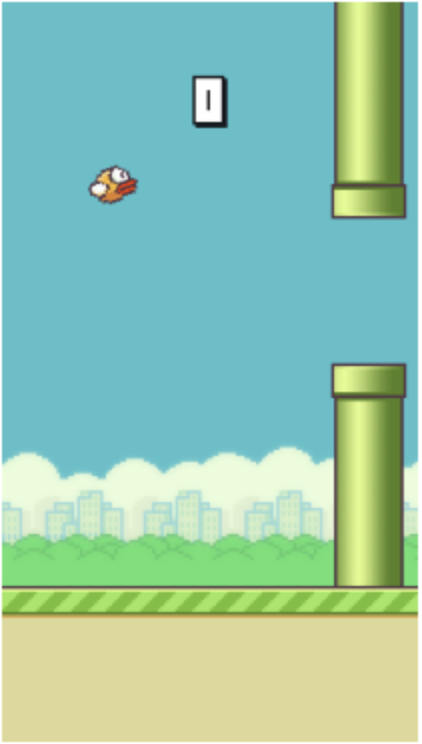

States:
the last pipe's horizontal position
the last top pipe's vertical position
the last bottom pipe's vertical position
the next pipe's horizontal position
the next top pipe's vertical position
the next bottom pipe's vertical position
the next next pipe's horizontal position
the next next top pipe's vertical position
the next next bottom pipe's vertical position
player's vertical position
player's vertical velocity
player's rotation

Actions:
0 - do nothing
1 - flap

Rewards
+0.1 - every frame it stays alive
+1.0 - successfully passing a pipe
-1.0 - dying
−0.5 - touch the top of the screen

# Library Installation and Initialize Parameters

In [1]:
%pip install -q gymnasium stable-baselines3 matplotlib pygame imageio ipywidgets gdown shimmy>=2.0


In [2]:
import os
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple, Union
from enum import IntEnum
from itertools import cycle

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

import pygame
from pygame import Rect
from pygame import image as pyg_image
from pygame.transform import flip as img_flip

import gymnasium
import imageio

from IPython.display import Image, display

from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy

SEED = 7
np.random.seed(SEED)

pygame 2.6.1 (SDL 2.28.4, Python 3.12.13)
Hello from the pygame community. https://www.pygame.org/contribute.html


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
# SET UP CONSTANTS
PIPE_VEL_X = -4
PLAYER_MAX_VEL_Y = 10  # max vel along Y, max descend speed
PLAYER_MIN_VEL_Y = -8  # min vel along Y, max ascend speed
PLAYER_ACC_Y = 1  # players downward acceleration
PLAYER_VEL_ROT = 3  # angular speed
PLAYER_FLAP_ACC = -9  # players speed on flapping
PLAYER_WIDTH = 34
PLAYER_HEIGHT = 24
PLAYER_PRIVATE_ZONE = (max(PLAYER_WIDTH, PLAYER_HEIGHT) + 30) / 2
LIDAR_MAX_DISTANCE = int(288 * 0.8) - PLAYER_WIDTH
PIPE_WIDTH = 52
PIPE_HEIGHT = 320
BASE_WIDTH = 336
BASE_HEIGHT = 112
BACKGROUND_WIDTH = 288
BACKGROUND_HEIGHT = 512
PLAYER_ROT_THR = 20 #: Player's rotation threshold.
FILL_BACKGROUND_COLOR = (200, 200, 200) #: Color to fill the surface's background when no background image was loaded.


Download Image Access: https://drive.google.com/file/d/1waxu759EIPvJG0AIMtRpgO3Uy8OrLIT7/view?usp=sharing.

Place zip file in the content folder in this notebook.

Run the code below to extract images.

In [4]:
# Download Flappy Bird sprites (auto-download for Colab)
import os
import zipfile

def get_base_dir():
    return "/content" if os.path.exists("/content") else os.getcwd()

base = get_base_dir()
sprites_dir = os.path.join(base, "sprites")
zip_path = os.path.join(base, "sprites.zip")

if not os.path.exists(os.path.join(sprites_dir, "background-day.png")):
    if not os.path.exists(zip_path):
        %pip install -q gdown
        import gdown
        gdown.download(
            "https://drive.google.com/uc?id=1waxu759EIPvJG0AIMtRpgO3Uy8OrLIT7",
            zip_path,
            quiet=False,
        )
    os.makedirs(base, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(base)
    print("Sprites extracted to", base)
else:
    print("Sprites already available.")

os.chdir(base)


Downloading...
From: https://drive.google.com/uc?id=1waxu759EIPvJG0AIMtRpgO3Uy8OrLIT7
To: /content/sprites.zip
100%|██████████| 34.9k/34.9k [00:00<00:00, 27.8MB/s]

Sprites extracted to /content


Run below scripts to set up visualization scripts

In [5]:

SPRITES_PATH = "sprites"


def pixel_collision(
    rect1: Rect, rect2: Rect, hitmask1: List[List[bool]], hitmask2: List[List[bool]]
) -> bool:
    """Checks if two objects collide and not just their rects."""
    rect = rect1.clip(rect2)

    if rect.width == 0 or rect.height == 0:
        return False

    x1, y1 = rect.x - rect1.x, rect.y - rect1.y
    x2, y2 = rect.x - rect2.x, rect.y - rect2.y

    for x in range(rect.width):
        for y in range(rect.height):
            if hitmask1[x1 + x][y1 + y] and hitmask2[x2 + x][y2 + y]:
                return True
    return False


def get_hitmask(image) -> List[List[bool]]:
    """Returns a hitmask using an image's alpha."""
    mask = []
    for x in range(image.get_width()):
        mask.append([])
        for y in range(image.get_height()):
            mask[x].append(bool(image.get_at((x, y))[3]))
    return mask


def _load_sprite(filename: str, convert: bool, alpha: bool = True):
    img_path = Path(SPRITES_PATH) / filename
    img = pyg_image.load(str(img_path))
    return (
        img.convert_alpha() if convert and alpha else img.convert() if convert else img
    )


def load_images(
    convert: bool = False,
    bg_type: Optional[str] = "day",
    bird_color: str = "yellow",
    pipe_color: str = "green",
) -> Dict[str, Any]:
    """Loads and returns the image assets of the game."""
    images = {}

    try:
        images["numbers"] = tuple(
            _load_sprite(f"{n}.png", convert=convert, alpha=True) for n in range(10)
        )

        images["gameover"] = _load_sprite("gameover.png", convert=convert, alpha=True)
        images["message"] = _load_sprite("message.png", convert=convert, alpha=True)
        images["base"] = _load_sprite("base.png", convert=convert, alpha=True)

        if bg_type is None:
            images["background"] = None
        else:
            images["background"] = _load_sprite(
                f"background-{bg_type}.png", convert=convert, alpha=False
            )

        images["player"] = (
            _load_sprite(f"{bird_color}bird-upflap.png", convert=convert, alpha=True),
            _load_sprite(f"{bird_color}bird-midflap.png", convert=convert, alpha=True),
            _load_sprite(f"{bird_color}bird-downflap.png", convert=convert, alpha=True),
        )

        pipe_sprite = _load_sprite(
            f"pipe-{pipe_color}.png", convert=convert, alpha=True
        )
        images["pipe"] = (img_flip(pipe_sprite, False, True), pipe_sprite)

    except FileNotFoundError as ex:
        raise FileNotFoundError(
            f"Can't find sprite files in: {SPRITES_PATH}\n"
        ) from ex

    return images

# Build a Flappy Bird Environment

In [6]:
class Actions(IntEnum):
    """Possible actions for the player to take."""

    IDLE, FLAP = 0, 1


class FlappyBirdEnv(gymnasium.Env):
    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 30}

    def __init__(
        self,
        render_mode: Optional[str] = None,
        score_limit: Optional[int] = None,
    ) -> None:
        self.action_space = gymnasium.spaces.Discrete(1) # MODIFY THIS
        self.observation_space = gymnasium.spaces.Box( # MODIFY THIS
            -np.inf, np.inf, shape=(1,), dtype=np.float64
        )
        self._set_flappy_bird_configuration(render_mode, score_limit)

    def reset(self, seed=None, options=None):
        """Resets the environment (starts a new game)."""
        super().reset(seed=seed)
        self._reset_environment_configuration()
# Agent Observe the environment
        obs, _ = np.array([0]), None #MODIFY THIS
        # Return a 12 observations of the states
            # the last pipe's horizontal position
            # the last top pipe's vertical position
            # the last bottom pipe's vertical position
            # the next pipe's horizontal position
            # the next top pipe's vertical position
            # the next bottom pipe's vertical position
            # the next next pipe's horizontal position
            # the next next top pipe's vertical position
            # the next next bottom pipe's vertical position
            # player's vertical position
            # player's vertical velocity
            # player's rotation
        # Example: Obs: [ 92. 160. 260. 236. 160. 260. 288.   0. 512. -75.   4.   6.]

        info = {"score": self._score}
        return obs, info


    def step(
        self,
        action: Union[Actions, int],
    ) -> Tuple[np.ndarray, float, bool, Dict]:

        terminal = False
        reward = None
# Agent Do an Action
        if action == Actions.FLAP:
            if self._player_y > -2 * PLAYER_HEIGHT:
                self._player_vel_y = PLAYER_FLAP_ACC
                self._player_flapped = True

# Agent Pass a Pipe
        # check for score
        player_mid_pos = self._player_x + PLAYER_WIDTH / 2
        for pipe in self._upper_pipes:
            pipe_mid_pos = pipe["x"] + PIPE_WIDTH / 2
            if pipe_mid_pos <= player_mid_pos < pipe_mid_pos + 4:
                self._score += 1
                # Reward for passing a pipe
                reward = 0

# State Transition Function (Player Change Position)
        # player_index base_x change
        if (self._loop_iter + 1) % 3 == 0:
            self._player_idx = next(self._player_idx_gen)

        self._loop_iter = (self._loop_iter + 1) % 30
        self._ground["x"] = -((-self._ground["x"] + 100) % self._base_shift)

        # rotate the player
        if self._player_rot > -90:
            self._player_rot -= PLAYER_VEL_ROT

        # player's movement
        if self._player_vel_y < PLAYER_MAX_VEL_Y and not self._player_flapped:
            self._player_vel_y += PLAYER_ACC_Y

        if self._player_flapped:
            self._player_flapped = False

            # more rotation to cover the threshold
            # (calculated in visible rotation)
            self._player_rot = 45

        self._player_y += min(
            self._player_vel_y, self._ground["y"] - self._player_y - PLAYER_HEIGHT
        )
# State Transition Function (The Pipes Move)
        # move pipes to left
        for up_pipe, low_pipe in zip(self._upper_pipes, self._lower_pipes):
            up_pipe["x"] += PIPE_VEL_X
            low_pipe["x"] += PIPE_VEL_X

            # it is out of the screen
            if up_pipe["x"] < -PIPE_WIDTH:
                new_up_pipe, new_low_pipe = self._get_random_pipe()
                up_pipe["x"] = new_up_pipe["x"]
                up_pipe["y"] = new_up_pipe["y"]
                low_pipe["x"] = new_low_pipe["x"]
                low_pipe["y"] = new_low_pipe["y"]

# Get New Observation
        obs, _ = np.array([0]), None #MODIFY THIS
        if reward is None:
            # MODIFY THIS
            reward = 0  # reward for staying alive


        # agent touch the top of the screen as punishment
        if self._player_y < 0:
          # MODIFY THIS
            reward = 0

        # check for crash
        if self._check_crash():
            # MODIFY THIS
            reward = 0  # reward for dying
            terminal = True
            self._player_vel_y = 0

        info = {"score": self._score}

        return (
            obs,
            reward,
            terminal,
            (self._score_limit is not None) and (self._score >= self._score_limit),
            info,
        )

    def render(self) -> None:
        """Renders the next frame."""
        if self.render_mode == "rgb_array":
            self._draw_surface(show_score=True)
            # Flip the image to retrieve a correct aspect
            return np.transpose(pygame.surfarray.array3d(self._surface), axes=(1, 0, 2))
        else:
            self._draw_surface(show_score=True)
            if self._display is None:
                self._make_display()

            self._update_display()
            self._fps_clock.tick(self.metadata["render_fps"])

    def close(self):
        """Closes the environment."""
        if self.render_mode is not None:
            pygame.display.quit()
            pygame.quit()
        super().close()

    def _reset_environment_configuration(self) -> None:
        """Reset player state, respawn pipes, and draw first frame in human mode."""
        self._player_x = int(self._screen_width * 0.2)
        self._player_y = int((self._screen_height - PLAYER_HEIGHT) / 2)
        self._player_vel_y = -9  # player"s velocity along Y
        self._player_rot = 45  # player"s rotation
        self._player_idx = 0
        self._loop_iter = 0
        self._score = 0

        new_pipe1 = self._get_random_pipe()
        new_pipe2 = self._get_random_pipe()
        new_pipe3 = self._get_random_pipe()

        self._upper_pipes = [
            {"x": self._screen_width, "y": new_pipe1[0]["y"]},
            {
                "x": self._screen_width + (self._screen_width / 2),
                "y": new_pipe2[0]["y"],
            },
            {
                "x": self._screen_width + self._screen_width,
                "y": new_pipe3[0]["y"],
            },
        ]

        self._lower_pipes = [
            {"x": self._screen_width, "y": new_pipe1[1]["y"]},
            {
                "x": self._screen_width + (self._screen_width / 2),
                "y": new_pipe2[1]["y"],
            },
            {
                "x": self._screen_width + self._screen_width,
                "y": new_pipe3[1]["y"],
            },
        ]

    def _set_flappy_bird_configuration(
        self,
        render_mode: Optional[str],
        score_limit: Optional[int],
        ) -> None:
        """Apply fixed game/render settings (resolution, assets, ground, pygame)."""
        assert render_mode is None or render_mode in self.metadata["render_modes"]
        self.render_mode = render_mode
        self._score_limit = score_limit
        self._screen_width = 288
        self._screen_height = 512
        self._pipe_gap = 100
        self._sound_cache = None
        self._player_flapped = False
        self._player_idx_gen = cycle([0, 1, 2, 1])
        self._bird_color = "yellow"
        self._pipe_color = "green"
        self._bg_type = "day"

        self._ground = {"x": 0, "y": self._screen_height * 0.79}
        self._base_shift = BASE_WIDTH - BACKGROUND_WIDTH

        if render_mode is not None:
            self._fps_clock = pygame.time.Clock()
            self._display = None
            self._surface = pygame.Surface((288, 512))
            self._images = load_images(
                convert=False,
                bird_color="yellow",
                pipe_color="green",
                bg_type="day",
            )

    def _get_random_pipe(self) -> Dict[str, int]:
        """Returns a randomly generated pipe."""
        # y of gap between upper and lower pipe
        gapYs = [20, 30, 40, 50, 60, 70, 80, 90]
        index = self.np_random.integers(0, len(gapYs))
        gap_y = gapYs[index]
        gap_y += int(self._ground["y"] * 0.2)

        pipe_x = self._screen_width + PIPE_WIDTH + (self._screen_width * 0.2)
        return [
            {"x": pipe_x, "y": gap_y - PIPE_HEIGHT},  # upper pipe
            {"x": pipe_x, "y": gap_y + self._pipe_gap},  # lower pipe
        ]

    def _check_crash(self) -> bool:
        """Returns True if player collides with the ground (base) or a pipe."""
        # if player crashes into ground
        if self._player_y + PLAYER_HEIGHT >= self._ground["y"] - 1:
            return True
        else:
            player_rect = pygame.Rect(
                self._player_x, self._player_y, PLAYER_WIDTH, PLAYER_HEIGHT
            )

            for up_pipe, low_pipe in zip(self._upper_pipes, self._lower_pipes):
                # upper and lower pipe rects
                up_pipe_rect = pygame.Rect(
                    up_pipe["x"], up_pipe["y"], PIPE_WIDTH, PIPE_HEIGHT
                )
                low_pipe_rect = pygame.Rect(
                    low_pipe["x"], low_pipe["y"], PIPE_WIDTH, PIPE_HEIGHT
                )

                # check collision
                up_collide = player_rect.colliderect(up_pipe_rect)
                low_collide = player_rect.colliderect(low_pipe_rect)

                if up_collide or low_collide:
                    return True

        return False

    def _get_observation(self):
        """12D raw feature observation; second value is unused (no lidar bonus)."""
        pipes = []
        for up_pipe, low_pipe in zip(self._upper_pipes, self._lower_pipes):
            # the pipe is behind the screen?
            if low_pipe["x"] > self._screen_width:
                pipes.append((self._screen_width, 0, self._screen_height))
            else:
                pipes.append(
                    (low_pipe["x"], (up_pipe["y"] + PIPE_HEIGHT), low_pipe["y"])
                )

        pipes = sorted(pipes, key=lambda x: x[0])
        pos_y = self._player_y
        vel_y = self._player_vel_y
        rot = self._player_rot

        return (
            np.array(
                [
                    pipes[0][0],
                    pipes[0][1],
                    pipes[0][2],
                    pipes[1][0],
                    pipes[1][1],
                    pipes[1][2],
                    pipes[2][0],
                    pipes[2][1],
                    pipes[2][2],
                    pos_y,
                    vel_y,
                    rot,
                ],
                dtype=np.float64,
            ),
            None,
        )

    def _make_display(self) -> None:
        """Initializes the pygame's display.

        Required for drawing images on the screen.
        """
        self._display = pygame.display.set_mode(
            (self._screen_width, self._screen_height)
        )
        for name, value in self._images.items():
            if value is None:
                continue

            if type(value) in (tuple, list):
                self._images[name] = tuple([img.convert_alpha() for img in value])
            else:
                self._images[name] = (
                    value.convert() if name == "background" else value.convert_alpha()
                )

    def _draw_score(self) -> None:
        """Draws the score in the center of the surface."""
        score_digits = [int(x) for x in list(str(self._score))]
        total_width = 0  # total width of all numbers to be printed

        for digit in score_digits:
            total_width += self._images["numbers"][digit].get_width()

        x_offset = (self._screen_width - total_width) / 2

        for digit in score_digits:
            self._surface.blit(
                self._images["numbers"][digit], (x_offset, self._screen_height * 0.1)
            )
            x_offset += self._images["numbers"][digit].get_width()

    def _draw_surface(self, show_score: bool = True) -> None:
        """Re-draws the renderer's surface.

        This method updates the renderer's surface by re-drawing it according to
        the current state of the game.

        Args:
            show_score (bool): Whether to draw the player's score or not.
        """
        # Background
        if self._images["background"] is not None:
            self._surface.blit(self._images["background"], (0, 0))
        else:
            self._surface.fill(FILL_BACKGROUND_COLOR)

        # Pipes
        for up_pipe, low_pipe in zip(self._upper_pipes, self._lower_pipes):
            self._surface.blit(self._images["pipe"][0], (up_pipe["x"], up_pipe["y"]))
            self._surface.blit(self._images["pipe"][1], (low_pipe["x"], low_pipe["y"]))

        # Base (ground)
        self._surface.blit(self._images["base"], (self._ground["x"], self._ground["y"]))

        # Getting player's rotation
        visible_rot = PLAYER_ROT_THR
        if self._player_rot <= PLAYER_ROT_THR:
            visible_rot = self._player_rot

        # Score
        # (must be drawn before the player, so the player overlaps it)
        if show_score:
            self._draw_score()

        # Player
        player_surface = pygame.transform.rotate(
            self._images["player"][self._player_idx],
            visible_rot,
        )
        player_surface_rect = player_surface.get_rect(
            topleft=(self._player_x, self._player_y)
        )
        self._surface.blit(player_surface, player_surface_rect)

    def _update_display(self) -> None:
        """Updates the display with the current surface of the renderer.

        A call to this method is usually preceded by a call to
        :meth:`.draw_surface()`. This method simply updates the display by
        showing the current state of the renderer's surface on it, it doesn't
        make any change to the surface.
        """
        if self._display is None:
            raise RuntimeError(
                "Tried to update the display, but a display hasn't been "
                "created yet! To create a display for the renderer, you must "
                "call the `make_display()` method."
            )

        pygame.event.get()
        self._display.blit(self._surface, [0, 0])
        pygame.display.update()


# Play the Environment

Randomly selecting actions

Total reward: 0


/usr/local/lib/python3.12/dist-packages/imageio/plugins/pillow.py:410: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(


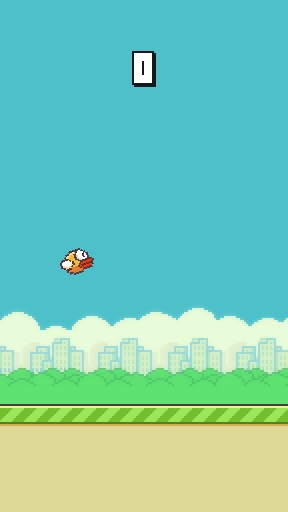

In [7]:
def play_random(render_mode="rgb_array"):
    env = FlappyBirdEnv(render_mode=render_mode)

    obs, _ = env.reset()
    done = False
    total_reward = 0

    frames = []

    # first frame
    frame = env.render()
    if frame is not None:
        frames.append(np.asarray(frame))

    while not done:
        # random action
        action = env.action_space.sample()

        # step
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward

        # render
        frame = env.render()
        if frame is not None:
            frames.append(np.asarray(frame))

        done = terminated or truncated

    print("Total reward:", total_reward)

    env.close()

    # save GIF
    gif_path = "flappy_random.gif"
    imageio.mimsave(gif_path, frames, fps=30)

    # show GIF
    display(Image(filename=gif_path))


if __name__ == "__main__":
    play_random()

Manual Play

In [8]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
total_reward = 0
env = FlappyBirdEnv(render_mode="rgb_array")
obs, _ = env.reset()
done = False

out = widgets.Output()

flap_btn = widgets.Button(description="Flap")
next_btn = widgets.Button(description="Next")

def step(action):
    global obs, done, total_reward

    if done:
        return

    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    with out:
        clear_output(wait=True)
        frame = env.render()
        plt.imshow(frame)
        plt.axis("off")
        plt.show()
        print("Observation:", obs)
        if (action == 1):
          print("Action: Flap")
        else:
          print("Action: Do nothing")

        if done:
            print("Game over")
            env.close()
        print("Step reward: ", reward)
        total_reward += reward
        print("Total reward: ", total_reward)


# Flap = action 1 + step
def on_flap_clicked(b):
    step(1)

# Next = action 0 + step
def on_next_clicked(b):
    step(0)

flap_btn.on_click(on_flap_clicked)
next_btn.on_click(on_next_clicked)

display(widgets.HBox([flap_btn, next_btn]))
display(out)

# first frame
with out:
    frame = env.render()
    plt.imshow(frame)
    plt.axis("off")
    plt.show()
    print("Observation:", obs)

Output()

# Train the Agent

In [9]:
import argparse
from pathlib import Path
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback

# --- Callback to record episode rewards during training ---
class RewardCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []
        self._current_reward = 0.0

    def _on_step(self) -> bool:
        self._current_reward += self.locals["rewards"][0]
        if self.locals["dones"][0]:
            self.episode_rewards.append(self._current_reward)
            self._current_reward = 0.0
        return True

def train(timesteps, save_path) -> None:

    # 1) Create one training environment (no rendering during training).
    env = FlappyBirdEnv(render_mode=None)

    # 2) Create a DQN model with a simple MLP policy.
    model = DQN("MlpPolicy", env, verbose=1)

    # 3) Train for the requested number of timesteps.
    model.learn(total_timesteps=timesteps, callback=callback)

    # 4) Save the trained model.
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    model.save(str(save_path))
    print(f"Saved model to {save_path}.zip")

    env.close()

callback = RewardCallback()
save_path = "models/flappy_dqn"
timesteps = 1000000
train(timesteps, save_path)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 31       |
|    ep_rew_mean      | 0        |
|    exploration_rate | 0.999    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 387      |
|    time_elapsed     | 0        |
|    total_timesteps  | 124      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.000482 |
|    n_updates        | 5        |
----------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Streaming output truncated to the last 5000 lines.
|    learning_rate    | 0.0001   |
|    loss             | 7.88e-08 |
|    n_updates        | 239635   |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 31       |
|    ep_rew_mean      | 0        |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 30928    |
|    fps              | 810      |
|    time_elapsed     | 1183     |
|    total_timesteps  | 958768   |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 1.89e-08 |
|    n_updates        | 239666   |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 31       |
|    ep_rew_mean      | 0        |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 30932    |
|    fps              | 810      |
|   

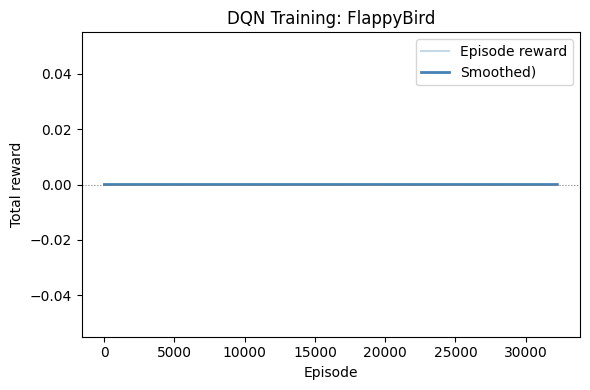

In [14]:
# --- Plot ---
rewards = np.array(callback.episode_rewards)
window = 20
smoothed = np.convolve(rewards, np.ones(window) / window, mode="valid")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(rewards, alpha=0.3, color="steelblue", label="Episode reward")
ax.plot(range(window - 1, len(rewards)), smoothed, color="steelblue", linewidth=2, label=f"Smoothed)")
ax.axhline(0, color="gray", linestyle=":", linewidth=0.8)
ax.set_xlabel("Episode")
ax.set_ylabel("Total reward")
ax.set_title("DQN Training: FlappyBird")
ax.legend()
plt.tight_layout()
plt.show()

# Evaluate the Agent

In [15]:
#!/usr/bin/env python3
"""Evaluate a trained Flappy Bird model."""

def run_stats(model: DQN, episodes: int, deterministic: bool) -> None:
    env = FlappyBirdEnv(render_mode=None)
    mean_reward, std_reward = evaluate_policy(
        model, env, n_eval_episodes=episodes, deterministic=deterministic
    )
    print(f"Episodes: {episodes}")
    print(f"Mean reward: {mean_reward:.2f}")
    print(f"Std reward: {std_reward:.2f}")
    env.close()


def run_rgb_array(
    model: DQN,
    episodes: int,
    deterministic: bool,
    gif_path: Path,
) -> None:
    """Evaluate with render_mode=rgb_array; save all episodes as one GIF."""
    env = FlappyBirdEnv(render_mode="rgb_array")
    all_frames: List[np.ndarray] = []

    for episode_idx in range(episodes):
        obs, _ = env.reset()
        terminated = False
        truncated = False
        total_reward = 0.0

        frame = env.render()
        if frame is not None:
            all_frames.append(np.asarray(frame))

        while not (terminated or truncated):
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward

            frame = env.render()
            if frame is not None:
                all_frames.append(np.asarray(frame))

        print(f"Episode {episode_idx + 1}/{episodes} reward: {total_reward:.2f}")

        # optional pause between episodes
        if frame is not None:
            last_frame = np.asarray(frame)
            for _ in range(10):
                all_frames.append(last_frame)

    env.close()

    if not all_frames:
        print("No frames captured; GIF not written.")
        return

    gif_path = Path(gif_path)
    gif_path.parent.mkdir(parents=True, exist_ok=True)

    h, w = all_frames[0].shape[0], all_frames[0].shape[1]
    fig, ax = plt.subplots(figsize=(w / 72, h / 72))
    ax.axis("off")
    im_artist = ax.imshow(all_frames[0])

    def _update(frame_idx: int):
        im_artist.set_array(all_frames[frame_idx])
        return (im_artist,)

    anim = animation.FuncAnimation(
        fig,
        _update,
        frames=len(all_frames),
        interval=1000 / 30,
        blit=False,
    )

    anim.save(str(gif_path), writer="pillow", fps=30)
    display(Image(filename=str(gif_path)))
    plt.close(fig)
    print(f"Saved all {episodes} episodes to {gif_path}")


def evaluate(model_path, mode, episodes, deterministic) -> None:
    model = DQN.load(str(model_path))
    gif_path = "flappy_evaluate.gif"

    if mode == "stats":
        run_stats(model, episodes, deterministic)
    elif mode == "rgb_array":
        run_rgb_array(
            model,
            episodes=episodes,
            deterministic=deterministic,
            gif_path=gif_path,
        )

Evaluation using Stats

In [12]:
model_path = "models/flappy_dqn"
mode = "stats"
episodes = 100
deterministic = False
evaluate(model_path, mode, episodes, deterministic)

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Episodes: 100
Mean reward: 0.00
Std reward: 0.00


Evaluation using Simulation

Episode 1/1 reward: 0.00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


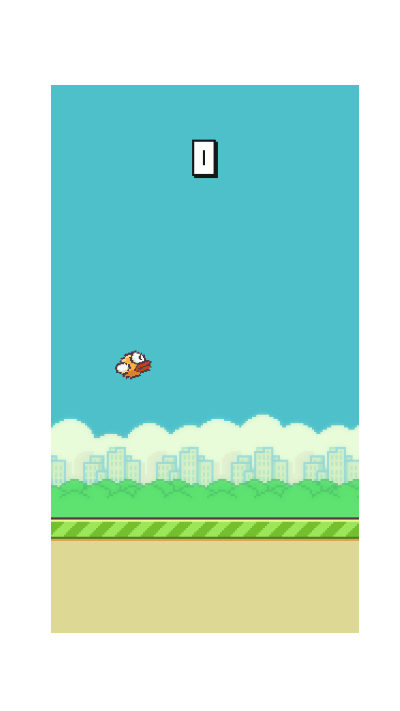

Saved all 1 episodes to flappy_evaluate.gif


In [13]:
model_path = "models/flappy_dqn"
mode = "rgb_array"
episodes = 1
deterministic = True
evaluate(model_path, mode, episodes, deterministic)